# Paleo wind from PMIP model output

Goal: get a 10 m wind speed for the site at past time slices (LGM ~21 ka,
mid-Holocene ~6 ka) instead of hand-scaling a proxy. PMIP4 (run under CMIP6) provides
standardised model runs and each carries a surface wind field. We take the cell nearest to the
site across several models, and use the multi-model mean as the estimate and the
spread as the uncertainty.

## Downloading the data 
1. Go to an ESGF node (the CMIP6 data search, e.g. esgf-node.llnl.gov).
2. Filter: **experiment_id** = `lgm` and `midHolocene`; **variable_id** = `sfcWind`
   (or `uas` + `vas` if sfcWind is absent); **frequency** = `mon` (monthly) then time-average,
   or `Amon` climatology.
3. Download a handful of models' NetCDF files into a `pmip/` folder.

Site: 15.01 N, 72.44 E.

## Understanding the NetCDF structure

A NetCDF file is a self-describing array format, and the data comes bundled with its own
labels, units, and metadata, unlike a CSV where you have to know externally what
each column means.

Dimensions vs coordinates vs data variables, three different roles:
- **Dimensions** (`time`, `lat`, `lon`) - the axes. They define the *shape* of the data
  (1200 × 120 × 180) but aren't values themselves, just the grid structure.
- **Coordinates** -  the actual tick-mark values along each dimension: which lat, which
  lon, which time each grid slot corresponds to. `ds.lat` gives the 120 latitude
  values; `ds.lon` gives the 180 longitude values.
- **Data variables** -  the actual measurements sitting *on* that grid. `sfcWind` is a
  data variable: one number for every (time, lat, lon) combination. `time_bnds`,
  `lat_bnds`, `lon_bnds` are bookkeeping, the start/end edges of each time-step and
  grid cell.

**`sfcWind`:** near-surface (10 m height) wind *speed*, a scalar,
already combining east-west and north-south wind into one magnitude. Units: m/s.

**What "model" means here:** each NetCDF file is the output of one climate model
(e.g. INM-CM4-8) run under one experiment (e.g. `lgm` = Last Glacial Maximum boundary
conditions: lower CO2, larger ice sheets, different orbital configuration). Different modeling
centers built physically independent models, so running the same experiment through
several of them and comparing answers is how PMIP estimates uncertainty, and agreement
between independent models is more trustworthy than one model alone.

In [ ]:
# just to chect what's inside the NetCDF file 
import glob
import xarray as xr

matches = sorted(glob.glob('pmip/lgm/AWI-ESM-1-1-LR/*.nc')) # makes a list of all the .nc files in the folder, sorted alphabetically
sample_file = matches[0] # takes the first file in the list (alphabetically) to use as a sample for inspection
print('Using:', sample_file) 
ds = xr.open_dataset(sample_file)

print(ds) # printing the dataset overview: variables, dimensions (time, lat, lon...), and their sizes. large block. 
print() # newline for readability
print('Variable names:', list(ds.data_vars)) # the variable names (should include 'sfcWind') 
print('Coordinate names:', list(ds.coords)) # axes the data is indexed by - typically 'time', 'lat', 'lon'.
print()
print('Latitude range: %.2f to %.2f, %d points' % (ds.lat.min(), ds.lat.max(), ds.lat.size))
print('Longitude range: %.2f to %.2f, %d points' % (ds.lon.min(), ds.lon.max(), ds.lon.size))
# confirms grid spacing and range, so you can judge whether your site's nearest cell is meaningfully close or is landing awkwardly (e.g. near a coastline).
print()
print('Time range:', ds.time.min().values, 'to', ds.time.max().values, '|', ds.time.size, 'steps')
# shows how much time the file covers and how many time-steps (months) it has, tells you whether one file is the WHOLE simulation or just one chunk of it.

Using: pmip/lgm/AWI-ESM-1-1-LR\sfcWind_Amon_AWI-ESM-1-1-LR_lgm_r1i1p1f1_gn_390101-390512.nc
<xarray.Dataset> Size: 4MB
Dimensions:    (time: 60, bnds: 2, lat: 96, lon: 192)
Coordinates:
  * time       (time) object 480B 3901-01-16 12:00:00 ... 3905-12-16 12:00:00
  * lat        (lat) float64 768B -88.57 -86.72 -84.86 ... 84.86 86.72 88.57
  * lon        (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 960B ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    sfcWind    (time, lat, lon) float32 4MB ...
Attributes: (12/37)
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           PMIP
    creation_date:         2020-03-15T15:25:46Z
    data_specs_version:    01.00.30
    experiment:            last glacial maximum
    experiment_id:         lgm
    ...                    ...
    title:                 AWI-ES

C:\Users\HP\AppData\Local\Temp\ipykernel_15448\367879353.py:8: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(sample_file)


## Model grid resolution comparison

Check each model's native grid before trusting the extracted wind values -
resolution is crucial near a coastline, since a coarser cell is more likely
to blend land and ocean together.

| Model | lat points | lon points | lat spacing | lon spacing |
|---|---|---|---|---|
| INM-CM4-8      | 120 | 180 | 1.5°   | 2.0°   | 
| AWI-ESM-1-1-LR | 96  | 192 | 1.875° | 1.875° | 
| MPI-ESM1-2-LR  | 96  | 192 | 1.875° | 1.875° | 

AWI and MPI share IDENTICAL grids (96 x 192, 1.875 deg both
directions) - not a coincidence; these two models likely share the same
underlying atmosphere component (a common practice between some modeling
centers), which is why their grids match exactly. INM is a different,
finer grid (1.5 deg lat).

## Plotting the NetCDF wind speed data at one time slice

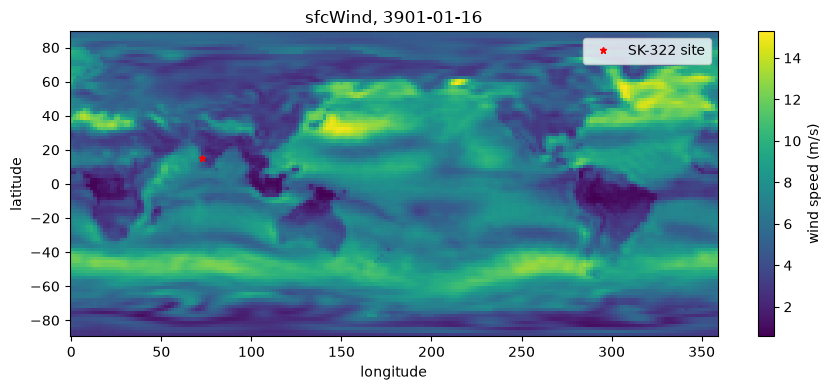

In [ ]:
import matplotlib.pyplot as plt # one time-slice (e.g. the first month)
snapshot = ds['sfcWind'].isel(time=0) # .isel (index-select) picks by position, time=0 means the very first time-step in the file

fig, ax = plt.subplots(figsize=(9, 4))
mesh = ax.pcolormesh(ds.lon, ds.lat, snapshot, cmap='viridis', shading='auto')

ax.plot(72.44, 15.01, 'r*', markersize=5, label='SK-322 site')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
ax.set_title('sfcWind, ' + str(ds.time.isel(time=0).values)[:10])
ax.legend()
fig.colorbar(mesh, ax=ax, label='wind speed (m/s)')
fig.tight_layout()

## Plotting the NetCDF wind speed data across 100 months

Saved wind_animation.gif
Open gif in main folder to see the animation.


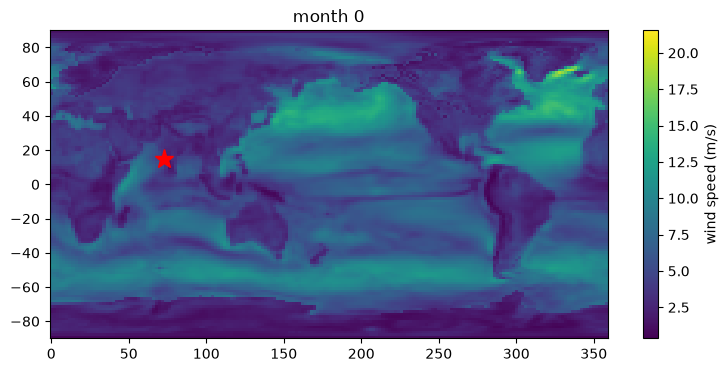

In [ ]:
import matplotlib.animation as animation

n_frames = 100 # full file has 1200 months; 100 frames is a fast preview, not the whole record
wind_data = ds['sfcWind'].isel(time=slice(0, n_frames))
# .isel(time=slice(0, n_frames)) takes the first n_frames time-steps only -

fig, ax = plt.subplots(figsize=(9, 4))
mesh = ax.pcolormesh(ds.lon, ds.lat, wind_data.isel(time=0), cmap='viridis', shading='auto', vmin=float(wind_data.min()), vmax=float(wind_data.max()))
# vmin/vmax are fixed across the whole animation (using the min/max over all frames). without this, matplotlib would rescale colors every frame

ax.plot(72.44, 15.01, 'r*', markersize=14)
title = ax.set_title('month 0')
fig.colorbar(mesh, ax=ax, label='wind speed (m/s)')

def update(frame):
    mesh.set_array(wind_data.isel(time=frame).values.ravel())
    # .set_array updates the EXISTING plot's colors instead of redrawing, much faster than making a new plot per frame
    # .ravel() flattens the 2D grid into 1D, which is the shape set_array expects
    title.set_text(f'month {frame}')
    return mesh, title

ani = animation.FuncAnimation(fig, update, frames=n_frames, blit=False)
ani.save('wind_animation.gif', writer='pillow', fps=8)
# 'pillow' is a GIF writer built into matplotlib - no ffmpeg or internet needed,
print('Saved wind_animation.gif')
print('Open gif in main folder to see the animation.')

## Loader and merger (after the files are locally downloaded)

`sfcWind` is already the scalar 10 m wind. If we only have `uas`/`vas`, they must be combined as sqrt(uas^2 + vas^2). Multiple netCDF fles are merged into one main file for each model to ensure time continuity and ease of data handling. 

- input: NetCDF files
- output: average wind speed per model (3x1 array)

In [ ]:
import numpy as np
import xarray as xr # xarray is the library that reads NetCDF files
import glob # pip install dask is a prerequisite for xarray to open multiple files, so make sure to run that in terminal

SITE_LAT, SITE_LON = 15.01, 72.44 # Core SK322-GC02 coordinates

model_folders = sorted(glob.glob('pmip/lgm/*')) # glob.glob('pmip/lgm/*') finds everything directly inside pmip/lgm/ 
# each match is a model's folder, not a file:['pmip/lgm/AWI-ESM-1-1-LR', 'pmip/lgm/INM-CM4-8', 'pmip/lgm/MPI-ESM1-2-LR']
# sorted() puts them in alphabetical order
winds = [] # will hold one wind value per model (of which there are three)

for folder in model_folders: # loops over each model's folder, "folder" holds the path, for eg. 'pmip/lgm/MPI-ESM1-2-LR'
    model_name = folder.split('/')[-1] # breaks the path every '/', 'pmip/lgm/MPI-ESM1-2-LR' and [-1] grabs the last piece
    ds = xr.open_mfdataset(f'{folder}/*sfcWind*.nc', combine='by_coords', use_cftime=True) #

    ''' most important line. open_mfdataset ("multi-file dataset") opens every
    matching file inside this one model's folder and stitches them together
    into a single continuous dataset instead of open_dataset, which only
    reads one file at a time.

    f'{folder}/*sfcWind*.nc' is an f-string: it drops the folder path directly
    into the pattern, e.g. 'pmip/lgm/MPI-ESM1-2-LR/*sfcWind*.nc' so it only
    grabs files belonging to THIS model, not all models at once.

    combine='by_coords' tells xarray how to stitch the files together: by
    matching up their shared coordinates (mainly time), so chunk 1900-1999
    and chunk 2000-2099 get joined end-to-end into one continuous timeline,
    rather than being randomly stacked.
    
    use_cftime=True is needed for some PMIP models that use a non-standard calendar
    (e.g. 360-day years) which xarray can't handle with its default datetime objects. 
    This is a known issue with PMIP data and xarray and in this specific case, it 
    was the last model (MPI-ESM1-2-LR) that required this argument to avoid a ValueError.
    '''

    w = ds['sfcWind'].mean('time') # pick windspeed, avg across the stitched timeline leaving one number per lat/lon cell
    cell = w.sel(lat=SITE_LAT, lon=SITE_LON, method='nearest') # grab the grid cell nearest your site's coordinates
    winds.append(float(cell)) #unwrap to a plain number, add it to the list which should contain 3 numbers, one per model
    print(f'{model_name}: {float(cell):.2f} m/s  ({len(ds.time)} months combined)') # eg outout = "MPI-ESM1-2-LR: 7.42 m/s  (3000 months combined)" 

winds = np.array(winds) # convert to a numpy array for math below

print('---')
print('LGM wind: %.2f +/- %.2f m/s  (n=%d models)' % (winds.mean(), winds.std(), len(winds)))
# mean, std deviation, and len(winds) correctly equals the number of model folders, which is 3 in this case

--- lgm\AWI-ESM-1-1-LR ---
grid cells in box: (4, 3)
[[6.5957823 5.9157176 4.992265 ]
 [6.597703  5.4462547 3.1762898]
 [6.3774757 5.0787663 4.0058084]
 [5.710811  3.2901525 3.0980062]]


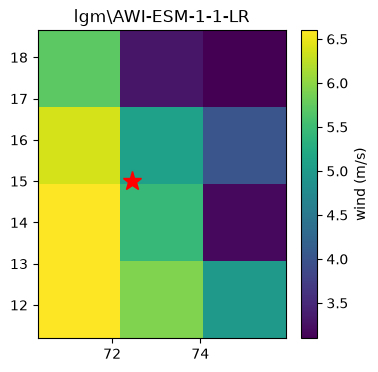

--- lgm\INM-CM4-8 ---
grid cells in box: (4, 3)
[[5.583957  5.8758254 4.481856 ]
 [5.8958635 5.4743633 3.116063 ]
 [6.200363  5.252959  2.8316712]
 [6.19458   4.5019493 2.8987877]]


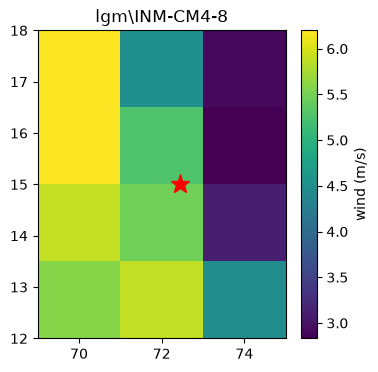

--- lgm\MPI-ESM1-2-LR ---
grid cells in box: (4, 3)
[[5.6294246 4.533914  3.5391126]
 [5.55279   3.958791  1.8393017]
 [5.572979  3.893735  2.3476706]
 [5.1036544 2.8701165 2.3759968]]


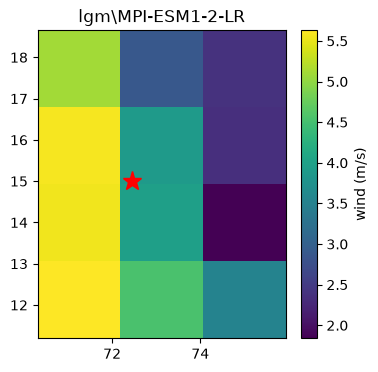

In [ ]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning) #prevent long output cell

for folder in model_folders:
    model_name = folder.split('/')[-1]
    files = sorted(glob.glob(f'{folder}/*sfcWind*.nc'))
    ds = xr.open_mfdataset(files, combine='by_coords', use_cftime=True)
    w = ds['sfcWind'].mean('time')

    box = w.sel(lat=slice(SITE_LAT - 3, SITE_LAT + 3), lon=slice(SITE_LON - 3, SITE_LON + 3))
    # .slice(min, max) instead of .sel(..., method='nearest') - grabs a range of cells (a 6-degree box centered on the site)

    print(f'--- {model_name} ---')
    print('grid cells in box:', box.shape)
    print(box.values)
    # prints the raw numbers as a small grid - if one cell is way lower/higher than its neighbors, that's a visual red flag for land contamination or
    # a data artifact, rather than genuine open-ocean wind.

    fig, ax = plt.subplots(figsize=(4, 4))
    mesh = ax.pcolormesh(box.lon, box.lat, box, cmap='viridis', shading='auto')
    ax.plot(SITE_LON, SITE_LAT, 'r*', markersize=14)
    ax.set_title(model_name)
    fig.colorbar(mesh, ax=ax, label='wind (m/s)')
    plt.show()


## Coastal contamination check - and fix

Box-averaging around the site (6x6 deg, all 3 models) revealed the site sits
almost exactly on the land-ocean boundary: wind is high (~6+ m/s, open Arabian
Sea) west of ~72.5E, and much lower (~2-4 m/s, land-influenced) east of it -
consistent across all three models, so this is a real geographic feature of
the site, not a model artifact.

Consequence: the "nearest cell" to the site's exact coordinates is a
land/ocean blended cell, not clean open water, which explains why the initial
multi-model wind estimate (4.74 +/- 0.60 m/s) read low compared to the modern
Arabian Sea monsoon (6-9 m/s). This was not a resolution problem (AWI and MPI
share an identical grid but still diverge) but rather a location problem.

Fix: I sample a cell offset ~2.5 deg WEST of the site instead of the
nearest cell - still close enough to represent the site's wind regime, but
now open ocean based on the box maps above.

## Nearest-cell vs open-ocean cell: LGM wind (m/s)

| Model          | Coastal (nearest) cell | Open-ocean cell (lon -2.5 deg) | Change |
|----------------|:-----------------------:|:-------------------------------:|:------:|
| AWI-ESM-1-1-LR | 5.08                    | 7.47                             | +2.39  |
| INM-CM4-8      | 5.25                    | 6.20                             | +0.95  |
| MPI-ESM1-2-LR  | 3.89                    | 6.92                             | +3.03  |
| **Mean +/- SD**| **4.74 +/- 0.60**       | **6.86 +/- 0.65**                |        |

**Takeaway:** the nearest-cell estimate was biased low by land contamination
at this near-coastal site - all three models sit right at the land/ocean
boundary, and their "nearest" cell blends both. Shifting the query point
~2.5 deg west into clearly open water (confirmed visually via the box maps)
raises the estimate by roughly +2 m/s and brings it in line with the modern
Arabian Sea SW-monsoon range (6-9 m/s), as expected for a physically
reasonable LGM wind. MPI-ESM1-2-LR shows the largest correction, consistent
with it having shown the most anomalous coastal-cell value initially.

## New average calculation after accounting for coastal influence:

In [14]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

for folder in model_folders:  # loop over each model's folder exactly as in the main wind-extraction cell, so this reruns the same process with one change
    model_name = folder.split('/')[-1]  
    files = sorted(glob.glob(f'{folder}/*sfcWind*.nc'))  
    ds = xr.open_mfdataset(files, combine='by_coords', use_cftime=True)  
    w = ds['sfcWind'].mean('time')  # pull out just the wind variable and average it over the whole time record, leaving one number per lat/lon grid cell
   
    #-----------------------------------------------------------------------------------------------
    # identical to abovementioned cell but lon has -2.5 to shift the query point west into open ocean, avoiding the coastal blend cell that sits right on the site
    ocean_cell = w.sel(lat=SITE_LAT, lon=SITE_LON - 2.5, method='nearest')  
    #-----------------------------------------------------------------------------------------------
    
    print(f'{model_name}: {float(ocean_cell):.2f} m/s (open-ocean cell)')  # unwrap to a plain number and print it labeled by model, so the three new values can be compared directly against the old coastal-cell values

lgm\AWI-ESM-1-1-LR: 7.47 m/s (open-ocean cell)
lgm\INM-CM4-8: 6.20 m/s (open-ocean cell)
lgm\MPI-ESM1-2-LR: 6.92 m/s (open-ocean cell)


In [ ]:
# LGM open-ocean wind values, one per model - computed in pmip_wind.ipynb,
# placed here as the final result so this cell runs without needing the
# NetCDF files or xarray again - just the three numbers already extracted exactly above

lgm_winds = {
    'AWI-ESM-1-1-LR': 7.47,
    'INM-CM4-8':       6.20,
    'MPI-ESM1-2-LR':   6.92,
}

lgm_wind_mean = np.mean(list(lgm_winds.values()))  # multi-model mean - your best estimate
lgm_wind_std  = np.std(list(lgm_winds.values()))   # multi-model spread - your uncertainty

print(f'LGM wind: {lgm_wind_mean:.2f} +/- {lgm_wind_std:.2f} m/s  (n={len(lgm_winds)} models)')

LGM wind: 6.86 +/- 0.52 m/s  (n=3 models)


## Using paleo wind data in eas_co2_flux.ipynb

Plug the multi-model mean into input u10 for the function gas_transfer_velocity within flux_physics.py for the LGM slice (and repeat for mid-Holocene after changing all relevant variables). PMIP resolution is coarse (a cell is hundreds of km), and monsoon winds are difficult for models to estimate with high levels of accuracy, so this is a constrained
estimate with error bars. 